In [1]:
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor 
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

In [14]:
site = 'B'
# df = pd.read_csv(base_fp+f'gulkana{site}_correlate.csv', parse_dates=True, index_col=0)
df = pd.read_csv(base_fp+f'all_df.csv', parse_dates=True, index_col=0)

drop_cols = ['albedo',
            #  'snow_depth',
             'oc_7d_rolling','oc_dep_cumsum',
             'snow_BC','snow_OC',
             'ddf_wBCOC', 'ddf_noBCOC',
             'diff_melt_cumsum']

for col in drop_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

target = 'diff_ddf'
df = df.loc[~df[target].isna()]
vars = np.array(df.columns[df.columns != target])

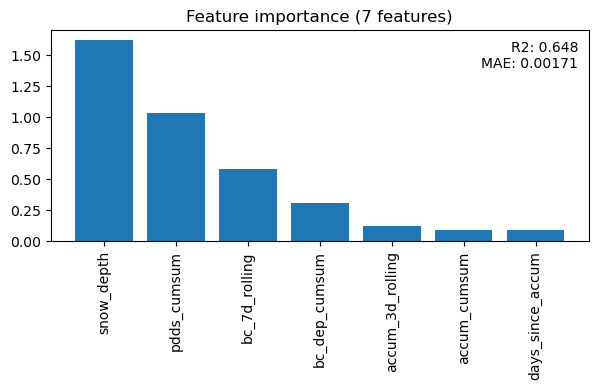

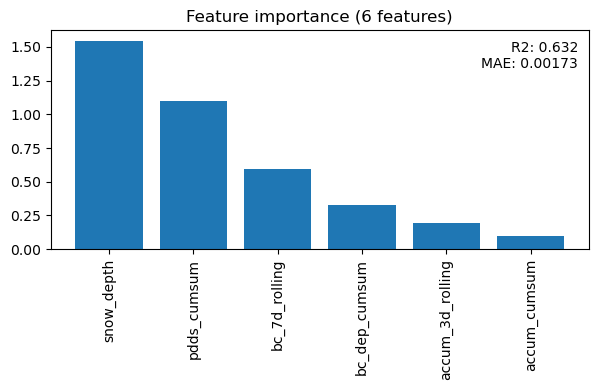

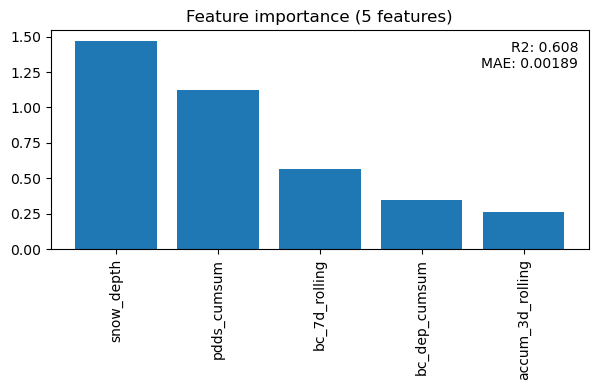

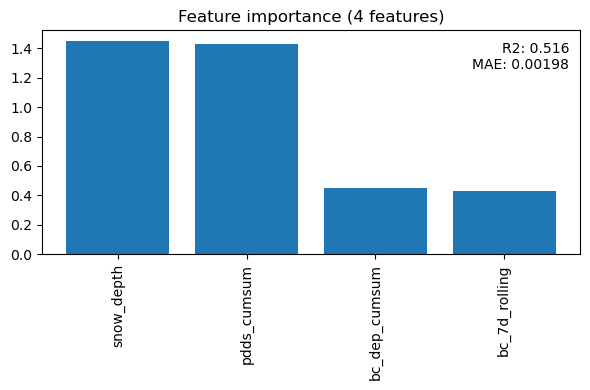

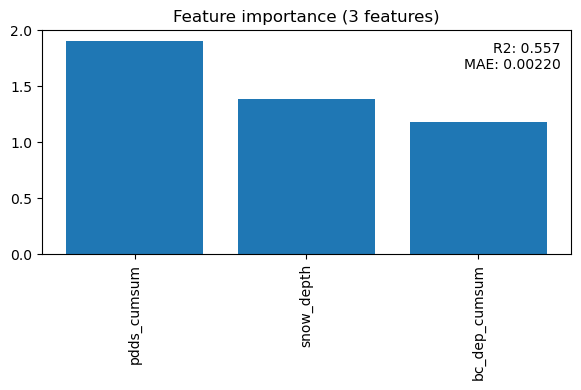

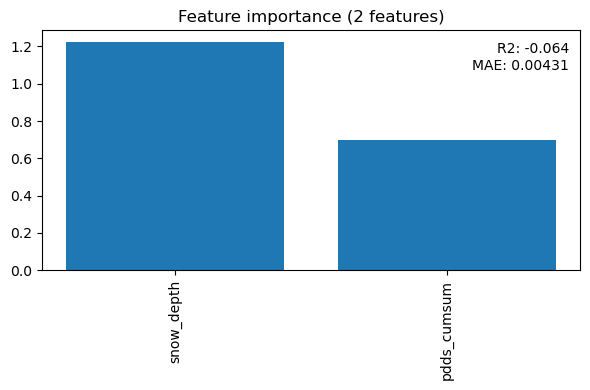

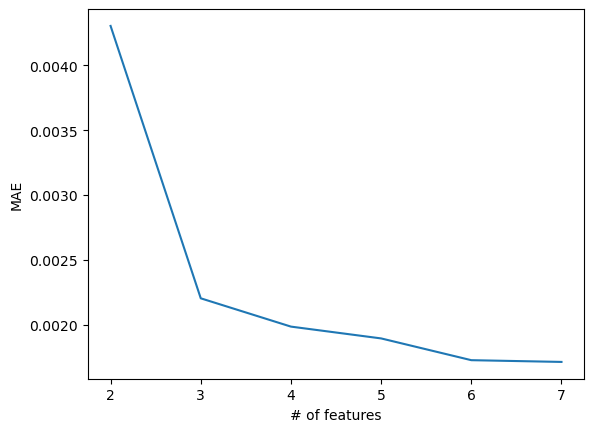

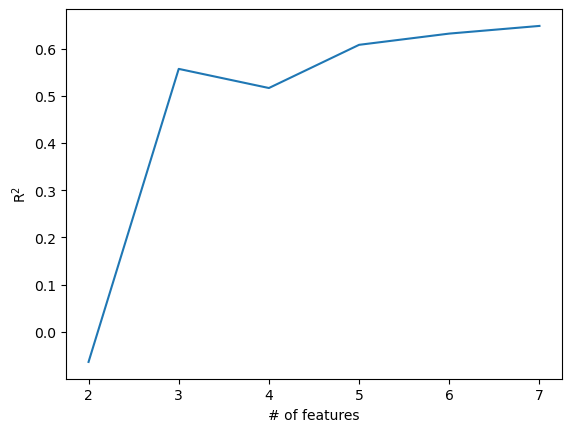

In [15]:
n_features = []
r2s = []
maes = []

while len(vars) > 1:
    X = df[vars]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=500, random_state=42)
    model.fit(X_train, y_train)

    perm = sk.inspection.permutation_importance(model, X_test, y_test, n_repeats=10)
    importances = perm.importances_mean
    indices = np.argsort(importances)[::-1]

    y_pred = model.predict(X_test)
    r2 = sk.metrics.r2_score(y_test, y_pred)
    mae = np.mean(np.abs(y_pred - y_test))

    r2s.append(r2)
    maes.append(mae)
    n_features.append(len(vars))

    plt.figure(figsize=(6,4))
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
    plt.text(0.98, 0.95, f'R2: {r2:.3f}\nMAE: {mae:.5f}',transform=plt.gca().transAxes,ha='right',va='top')
    plt.title(f"Feature importance ({len(X.columns)} features)")
    plt.tight_layout()
    plt.show()

    least_important = vars[indices[-1]]
    vars = vars[vars != least_important]

plt.plot(n_features, maes)
plt.ylabel('MAE')
plt.xlabel('# of features')
plt.show()

plt.plot(n_features, r2s)
plt.ylabel('R$^2$')
plt.xlabel('# of features')
plt.show()

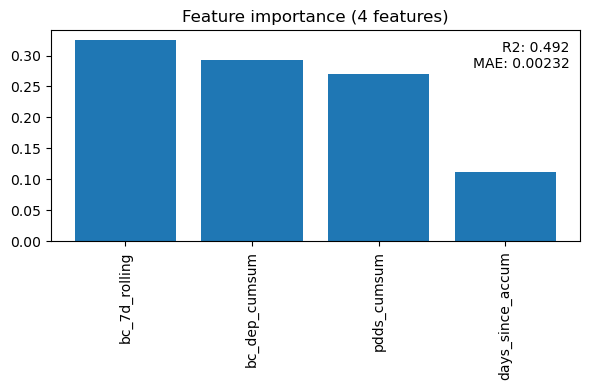

In [16]:
X = df[['bc_dep_cumsum','bc_7d_rolling','pdds_cumsum','days_since_accum']]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

y_pred = model.predict(X_test)
r2 = sk.metrics.r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_pred - y_test))

r2s.append(r2)
maes.append(mae)
n_features.append(len(X.columns))

plt.figure(figsize=(6,4))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.text(0.98, 0.95, f'R2: {r2:.3f}\nMAE: {mae:.5f}',transform=plt.gca().transAxes,ha='right',va='top')
plt.title(f"Feature importance ({len(X.columns)} features)")
plt.tight_layout()
plt.show()

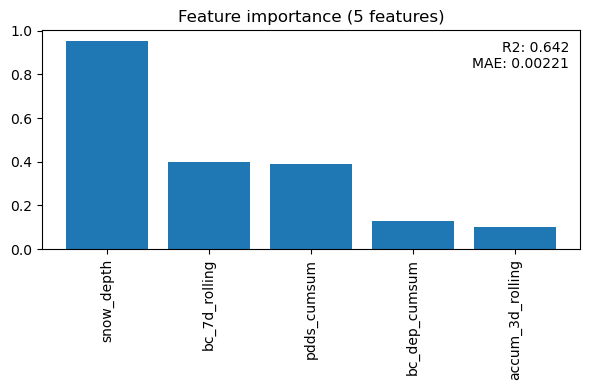

In [13]:
# GBR
vars = np.array(df.columns[df.columns != target])
exclude = ['days_since_accum','accum_cumsum']
vars = [v for v in vars if v not in exclude]
X = df[vars]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

perm = sk.inspection.permutation_importance(model, X_test, y_test, n_repeats=10)
importances = perm.importances_mean
indices = np.argsort(importances)[::-1]

y_pred = model.predict(X_test)
r2 = sk.metrics.r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_pred - y_test))

plt.figure(figsize=(6,4))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.text(0.98, 0.95, f'R2: {r2:.3f}\nMAE: {mae:.5f}',transform=plt.gca().transAxes,ha='right',va='top')
plt.title(f"Feature importance ({len(X.columns)} features)")
plt.tight_layout()
plt.show()

In [9]:
# linear regression
X = df[['bc_dep_cumsum','bc_7d_rolling','pdds_cumsum','days_since_accum']]
drop_from_X = ~X.isna().any(axis=1)
X = X.loc[drop_from_X]
y = df.loc[drop_from_X, target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
r2 = sk.metrics.r2_score(y_test, y_pred)
mae = sk.metrics.mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")

# Coefficients (feature importance for linear models)
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df)

R²: -0.005
MAE: 0.005
            feature   coefficient
3  days_since_accum -3.804249e-06
2       pdds_cumsum  1.543169e-07
0     bc_dep_cumsum  5.565030e-18
1     bc_7d_rolling -4.125289e-18


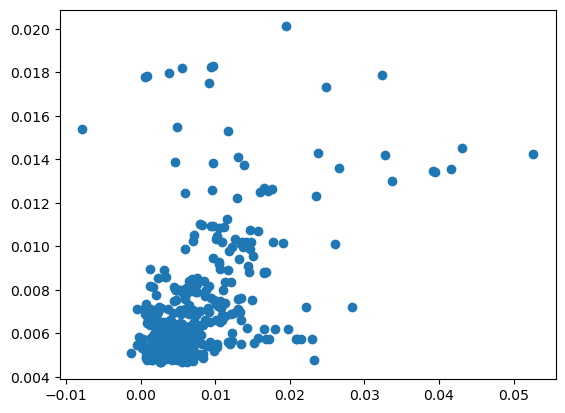

In [61]:
plt.scatter(y_test, y_pred)